# 02 — Feature Engineering

Compute ~19 technical indicators on OHLCV data. We'll develop the pipeline on a single stock (AAPL), then apply it to all test stocks.

**Key principle:** All features must be **relative** (ratios, percentages, bounded scales) — never absolute dollar values. This ensures the model generalizes across stocks at different price levels.

**Indicators:**
- Trend: Price/SMA50, Price/SMA200, Price/EMA20 ratios, MACD normalized (line + signal + histogram)
- Momentum: RSI (14), Stochastic Oscillator (%K, %D), ROC
- Volatility: Bollinger Band position (0–1), Bollinger bandwidth, ATR %
- Volume: OBV normalized, Volume/SMA ratio
- Price-derived: 52-week high/low distance, monthly returns (1m, 3m)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

In [2]:
# Fetch AAPL as our development stock
aapl = yf.download("AAPL", period="5y", auto_adjust=True)
print(f"Shape: {aapl.shape}")
print(f"Date range: {aapl.index.min().date()} to {aapl.index.max().date()}")
aapl.head()

[*********************100%***********************]  1 of 1 completed

Shape: (1255, 5)
Date range: 2021-03-24 to 2026-03-23


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-03-24,116.967125,119.704058,116.947648,119.626136,88530500
2021-03-25,117.454140,118.496322,115.905490,116.431449,98844700
2021-03-26,118.057991,118.320974,115.827540,117.220354,94071200
2021-03-29,118.233315,119.392372,117.590481,118.486555,80819200
2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900


## 1. Trend Indicators

In [3]:
df = aapl.copy()

# Flatten MultiIndex columns if present (yfinance sometimes returns them)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Compute raw moving averages (intermediate — not used as features directly)
sma_50 = df["Close"].rolling(window=50).mean()
sma_200 = df["Close"].rolling(window=200).mean()
ema_20 = df["Close"].ewm(span=20, adjust=False).mean()

# Price / MA ratios (>1 = price above average = bullish, <1 = bearish)
df["Price_SMA50_Ratio"] = df["Close"] / sma_50
df["Price_SMA200_Ratio"] = df["Close"] / sma_200
df["Price_EMA20_Ratio"] = df["Close"] / ema_20

# MACD normalized by price (makes it comparable across stocks)
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
macd_raw = ema_12 - ema_26
macd_signal_raw = macd_raw.ewm(span=9, adjust=False).mean()
df["MACD_Norm"] = macd_raw / df["Close"] * 100
df["MACD_Signal_Norm"] = macd_signal_raw / df["Close"] * 100
df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

print("Trend indicators added:")
df[["Close", "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm"]].tail()

Trend indicators added:


Price,Close,Price_SMA50_Ratio,Price_SMA200_Ratio,Price_EMA20_Ratio,MACD_Norm,MACD_Signal_Norm,MACD_Hist_Norm
Date,,,,,,,
2026-03-17,254.229996,0.970809,1.034563,0.977119,-1.211237,-0.706117,-0.505120
2026-03-18,249.940002,0.955673,1.016077,0.964246,-1.399366,-0.854463,-0.544903
2026-03-19,248.960007,0.952885,1.011110,0.964096,-1.551888,-0.996639,-0.555249
2026-03-20,247.990005,0.950052,1.006244,0.963981,-1.687038,-1.137837,-0.549201
2026-03-23,251.490005,0.964000,1.019426,0.979677,-1.633305,-1.224263,-0.409043


## 2. Momentum Indicators

In [4]:
# RSI (14-period)
delta = df["Close"].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

# Stochastic Oscillator (%K 14-period, %D 3-period SMA of %K)
low_14 = df["Low"].rolling(window=14).min()
high_14 = df["High"].rolling(window=14).max()
df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
df["Stoch_D"] = df["Stoch_K"].rolling(window=3).mean()

# Rate of Change (21-day ~ 1 month)
df["ROC"] = df["Close"].pct_change(periods=21) * 100

print("Momentum indicators added:")
df[["Close", "RSI", "Stoch_K", "Stoch_D", "ROC"]].tail()

Momentum indicators added:


Price,Close,RSI,Stoch_K,Stoch_D,ROC
Date,,,,,
2026-03-17,254.229996,40.815515,17.713407,10.793521,-0.605991
2026-03-18,249.940002,36.694893,3.947932,11.357346,-5.282705
2026-03-19,248.960007,35.805608,8.632366,10.097902,-5.821827
2026-03-20,247.990005,34.903948,9.875961,7.485420,-4.831523
2026-03-23,251.490005,40.706013,27.245693,15.251340,-4.947457


## 3. Volatility Indicators

In [5]:
# Bollinger Bands — compute raw bands, then derive relative features
bb_sma = df["Close"].rolling(window=20).mean()
bb_std = df["Close"].rolling(window=20).std()
bb_upper = bb_sma + 2 * bb_std
bb_lower = bb_sma - 2 * bb_std

# BB Position: where price sits within the bands (0 = at lower, 1 = at upper)
df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)

# BB Width: bandwidth normalized by SMA (already relative)
df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

# ATR as percentage of price (not raw dollar ATR)
high_low = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift(1)).abs()
low_close = (df["Low"] - df["Close"].shift(1)).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
atr_raw = true_range.rolling(window=14).mean()
df["ATR_Pct"] = atr_raw / df["Close"] * 100

print("Volatility indicators added:")
df[["Close", "BB_Position", "BB_Width", "ATR_Pct"]].tail()

Volatility indicators added:


Price,Close,BB_Position,BB_Width,ATR_Pct
Date,,,,
2026-03-17,254.229996,0.191132,0.097443,2.220429
2026-03-18,249.940002,0.085541,0.105765,2.276546
2026-03-19,248.960007,0.102175,0.114278,2.126847
2026-03-20,247.990005,0.121241,0.121841,2.045013
2026-03-23,251.490005,0.257258,0.123364,2.048931


## 4. Volume Indicators

In [6]:
# OBV normalized: 21-day net directional volume / average volume
# Measures buying vs selling pressure as a stock-independent ratio
obv_sign = np.sign(df["Close"].diff())
obv = (obv_sign * df["Volume"]).cumsum()
df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()

# Volume / 20-day SMA ratio (highlights unusual volume — already relative)
df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(window=20).mean()

print("Volume indicators added:")
df[["Close", "Volume", "OBV_Norm", "Vol_SMA_Ratio"]].tail()

Volume indicators added:


Price,Close,Volume,OBV_Norm,Vol_SMA_Ratio
Date,,,,
2026-03-17,254.229996,32361600,0.482072,0.831881
2026-03-18,249.940002,35757900,-1.936013,0.917353
2026-03-19,248.960007,34864100,-3.715288,0.889836
2026-03-20,247.990005,88268000,-4.853679,2.127439
2026-03-23,251.490005,37465587,-4.990953,0.902826


## 5. Price-Derived Features

In [7]:
# Distance from 52-week high and low (as percentage — already relative)
high_252 = df["High"].rolling(window=252).max()
low_252 = df["Low"].rolling(window=252).min()
df["Dist_52w_High"] = (df["Close"] - high_252) / high_252 * 100
df["Dist_52w_Low"] = (df["Close"] - low_252) / low_252 * 100

# Monthly returns (1-month ~21 trading days, 3-month ~63 trading days)
df["Return_1m"] = df["Close"].pct_change(periods=21) * 100
df["Return_3m"] = df["Close"].pct_change(periods=63) * 100

print("Price-derived features added:")
df[["Close", "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m"]].tail()

Price-derived features added:


Price,Close,Dist_52w_High,Dist_52w_Low,Return_1m,Return_3m
Date,,,,,
2026-03-17,254.229996,-11.832902,50.900078,-0.605991,-8.556896
2026-03-18,249.940002,-13.320674,48.353721,-5.282705,-8.732299
2026-03-19,248.960007,-13.660537,47.772038,-5.821827,-9.255681
2026-03-20,247.990005,-13.996934,47.196286,-4.831523,-8.688180
2026-03-23,251.490005,-12.783132,49.273737,-4.947457,-7.518525


## 6. Feature Summary & NaN Check

Some indicators need a warm-up period (e.g., SMA 200 needs 200 days). We'll check how many rows we lose.

In [8]:
feature_cols = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]

print(f"Total features: {len(feature_cols)}")
print(f"Total rows: {len(df)}")
print(f"\nNaN counts per feature:")
print(df[feature_cols].isnull().sum().to_string())

df_clean = df.dropna(subset=feature_cols)
print(f"\nRows after dropping NaN: {len(df_clean)} (lost {len(df) - len(df_clean)} warm-up rows)")

# Verify all features are relative (no raw dollar values)
print(f"\nFeature ranges (should be comparable across stocks):")
print(df_clean[feature_cols].describe().round(3).to_string())

Total features: 19
Total rows: 1255

NaN counts per feature:
Price
Price_SMA50_Ratio      49
Price_SMA200_Ratio    199
Price_EMA20_Ratio       0
MACD_Norm               0
MACD_Signal_Norm        0
MACD_Hist_Norm          0
RSI                    13
Stoch_K                13
Stoch_D                15
ROC                    21
BB_Position            19
BB_Width               19
ATR_Pct                13
OBV_Norm               22
Vol_SMA_Ratio          19
Dist_52w_High         251
Dist_52w_Low          251
Return_1m              21
Return_3m              63

Rows after dropping NaN: 1004 (lost 251 warm-up rows)

Feature ranges (should be comparable across stocks):
Price  Price_SMA50_Ratio  Price_SMA200_Ratio  Price_EMA20_Ratio  MACD_Norm  MACD_Signal_Norm  MACD_Hist_Norm       RSI   Stoch_K   Stoch_D       ROC  BB_Position  BB_Width   ATR_Pct  OBV_Norm  Vol_SMA_Ratio  Dist_52w_High  Dist_52w_Low  Return_1m  Return_3m
count           1004.000            1004.000           1004.000   1004.0

## 7. Visualization

Verify a few key indicators visually to make sure they look correct.

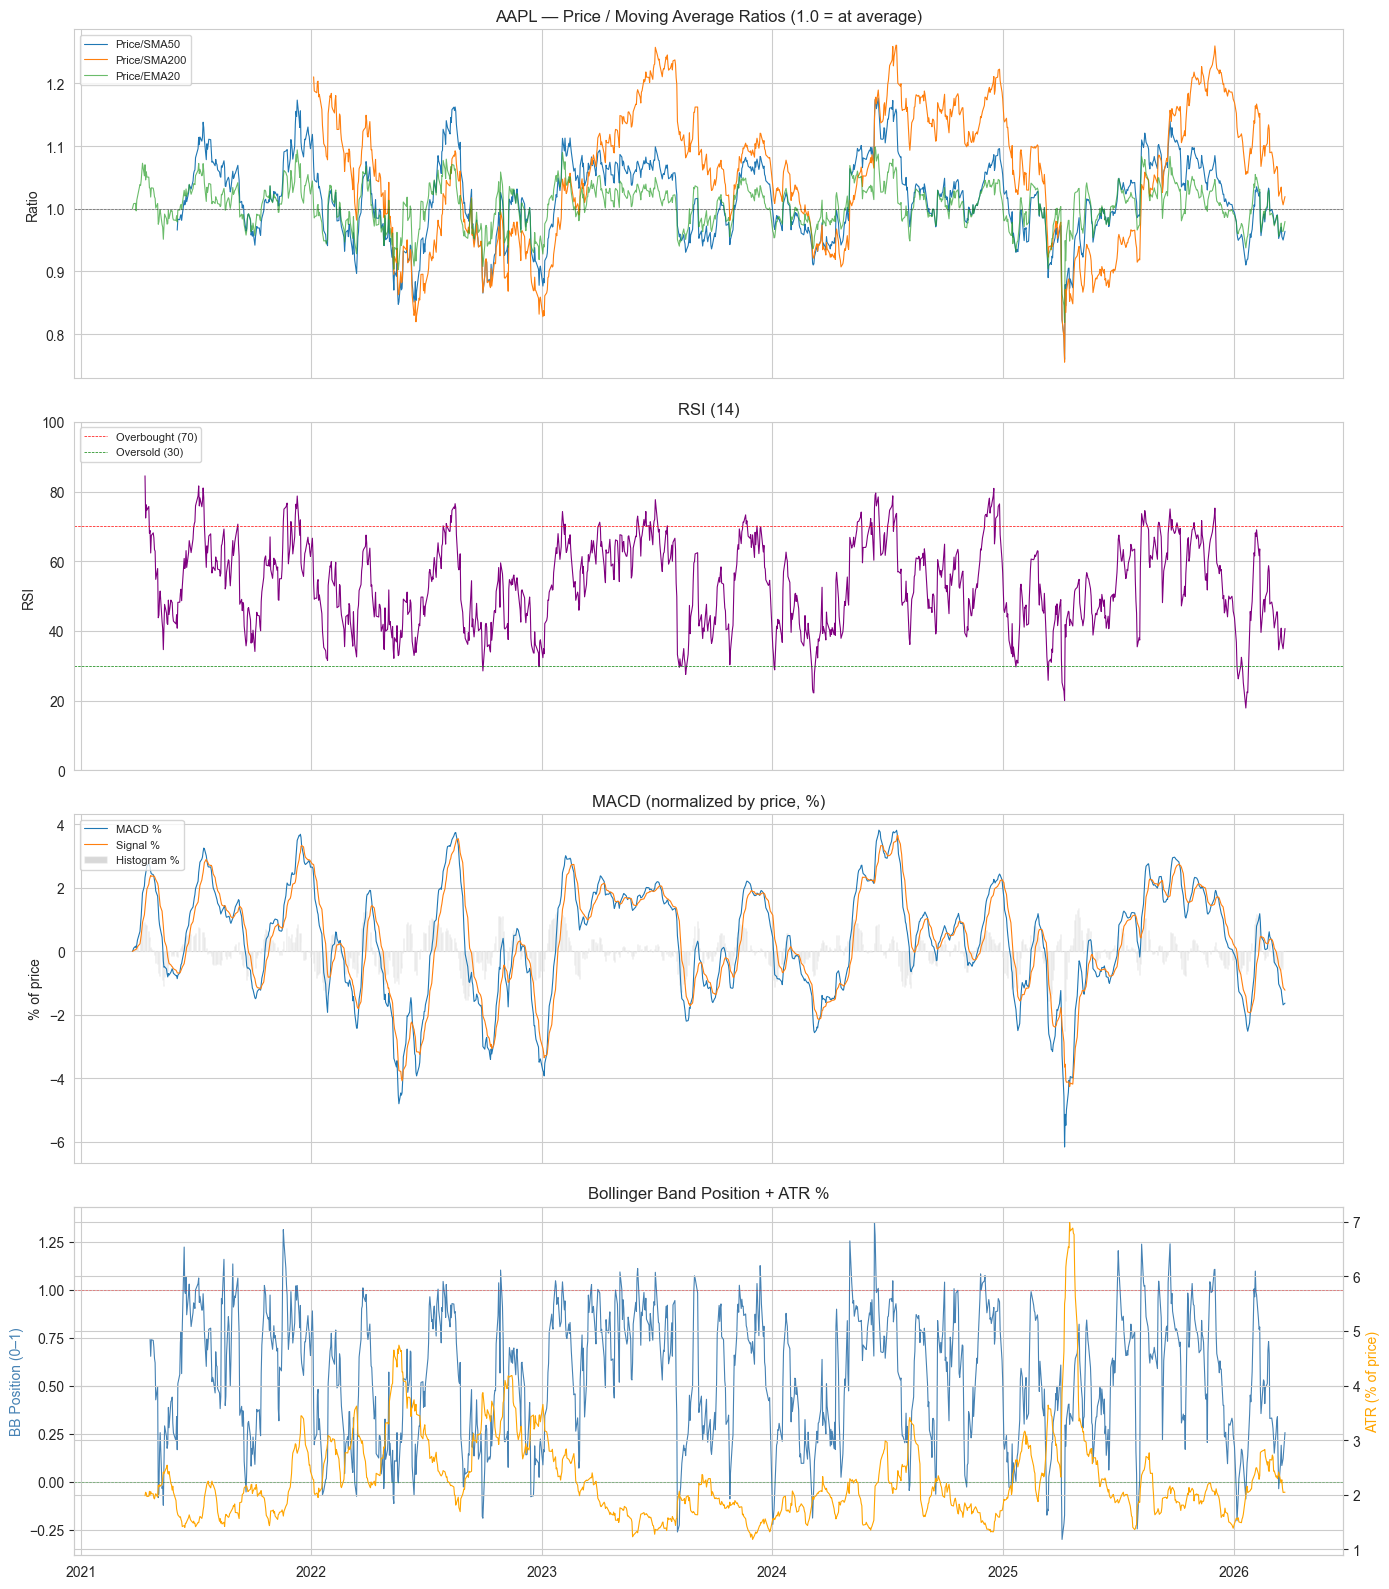

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# 1. Price with MA ratios
axes[0].plot(df.index, df["Price_SMA50_Ratio"], label="Price/SMA50", linewidth=0.8)
axes[0].plot(df.index, df["Price_SMA200_Ratio"], label="Price/SMA200", linewidth=0.8)
axes[0].plot(df.index, df["Price_EMA20_Ratio"], label="Price/EMA20", linewidth=0.8, alpha=0.7)
axes[0].axhline(y=1.0, color="black", linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].set_title("AAPL — Price / Moving Average Ratios (1.0 = at average)")
axes[0].set_ylabel("Ratio")
axes[0].legend(loc="upper left", fontsize=8)

# 2. RSI
axes[1].plot(df.index, df["RSI"], linewidth=0.8, color="purple")
axes[1].axhline(y=70, color="red", linestyle="--", linewidth=0.5, label="Overbought (70)")
axes[1].axhline(y=30, color="green", linestyle="--", linewidth=0.5, label="Oversold (30)")
axes[1].set_title("RSI (14)")
axes[1].set_ylabel("RSI")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left", fontsize=8)

# 3. Normalized MACD
axes[2].plot(df.index, df["MACD_Norm"], label="MACD %", linewidth=0.8)
axes[2].plot(df.index, df["MACD_Signal_Norm"], label="Signal %", linewidth=0.8)
axes[2].bar(df.index, df["MACD_Hist_Norm"], alpha=0.3, color="gray", label="Histogram %", width=1)
axes[2].set_title("MACD (normalized by price, %)")
axes[2].set_ylabel("% of price")
axes[2].legend(loc="upper left", fontsize=8)

# 4. BB Position + ATR %
ax4 = axes[3]
ax4.plot(df.index, df["BB_Position"], color="steelblue", linewidth=0.8, label="BB Position")
ax4.axhline(y=0, color="green", linestyle="--", linewidth=0.5, alpha=0.5)
ax4.axhline(y=1, color="red", linestyle="--", linewidth=0.5, alpha=0.5)
ax4.set_ylabel("BB Position (0–1)", color="steelblue")
ax4_twin = ax4.twinx()
ax4_twin.plot(df.index, df["ATR_Pct"], color="orange", linewidth=0.8, label="ATR %")
ax4_twin.set_ylabel("ATR (% of price)", color="orange")
ax4.set_title("Bollinger Band Position + ATR %")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 8. Reusable Feature Engineering Function

Package everything into a single function we can reuse in later notebooks and port to the ML service.

In [10]:
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all technical indicators on a DataFrame with OHLCV columns.
    
    All features are relative (ratios, percentages, bounded scales) so they
    generalize across stocks at different price levels.
    
    Expects columns: Open, High, Low, Close, Volume
    Returns the DataFrame with feature columns added (NaN rows from warm-up not dropped).
    """
    df = df.copy()
    
    # Flatten MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # --- Trend (ratios around 1.0) ---
    sma_50 = df["Close"].rolling(window=50).mean()
    sma_200 = df["Close"].rolling(window=200).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"] = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"] = df["Close"] / ema_20

    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_signal_raw = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"] = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_signal_raw / df["Close"] * 100
    df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    # --- Momentum (already bounded/relative) ---
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))
    
    low_14 = df["Low"].rolling(window=14).min()
    high_14 = df["High"].rolling(window=14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(window=3).mean()
    
    df["ROC"] = df["Close"].pct_change(periods=21) * 100

    # --- Volatility (relative) ---
    bb_sma = df["Close"].rolling(window=20).mean()
    bb_std = df["Close"].rolling(window=20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

    high_low = df["High"] - df["Low"]
    high_close = (df["High"] - df["Close"].shift(1)).abs()
    low_close = (df["Low"] - df["Close"].shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df["ATR_Pct"] = true_range.rolling(window=14).mean() / df["Close"] * 100

    # --- Volume (relative) ---
    obv_sign = np.sign(df["Close"].diff())
    obv = (obv_sign * df["Volume"]).cumsum()
    df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(window=20).mean()

    # --- Price-derived (percentages) ---
    high_252 = df["High"].rolling(window=252).max()
    low_252 = df["Low"].rolling(window=252).min()
    df["Dist_52w_High"] = (df["Close"] - high_252) / high_252 * 100
    df["Dist_52w_Low"] = (df["Close"] - low_252) / low_252 * 100
    df["Return_1m"] = df["Close"].pct_change(periods=21) * 100
    df["Return_3m"] = df["Close"].pct_change(periods=63) * 100

    return df

# Test it
test_df = compute_features(aapl)
feature_cols = [c for c in test_df.columns if c not in ["Open", "High", "Low", "Close", "Volume"]]
test_clean = test_df.dropna(subset=feature_cols)
print(f"Features: {len(feature_cols)}")
print(f"Rows: {len(test_df)} -> {len(test_clean)} after warm-up drop")
print(f"Columns: {feature_cols}")

Features: 19
Rows: 1255 -> 1004 after warm-up drop
Columns: ['Price_SMA50_Ratio', 'Price_SMA200_Ratio', 'Price_EMA20_Ratio', 'MACD_Norm', 'MACD_Signal_Norm', 'MACD_Hist_Norm', 'RSI', 'Stoch_K', 'Stoch_D', 'ROC', 'BB_Position', 'BB_Width', 'ATR_Pct', 'OBV_Norm', 'Vol_SMA_Ratio', 'Dist_52w_High', 'Dist_52w_Low', 'Return_1m', 'Return_3m']
